In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
df=pd.read_csv("heart.csv")
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
shuffled_df = df.sample(n=len(df),random_state=42)

shuffled_df


,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0


In [4]:
shuffled_df = shuffled_df.reset_index(drop=True)
shuffled_df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
1,59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
2,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
3,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
4,71,0,2,110,265,1,0,130,0,0.0,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0
299,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
300,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
301,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0


In [5]:
df=shuffled_df

In [6]:
class_counts = df['output'].value_counts()
class_counts

output
1    165
0    138
Name: count, dtype: int64

In [7]:
new_columns=['age', 'gender','cp',
             'trtbps','chol','fbs',
             'rest_ecg','thalach',
             'exng','oldpeak',
             'slope','ca',
             'thal','target']


In [8]:
df.columns=new_columns
df

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
0,57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
1,59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
2,57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
3,56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
4,71,0,2,110,265,1,0,130,0,0.0,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,233,0,1,163,0,0.6,1,1,3,0
299,51,1,2,94,227,0,1,154,1,0.0,2,1,3,1
300,69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
301,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0


In [9]:
df.shape

(303, 14)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   gender    303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   rest_ecg  303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
# in this dataset there are no missing values, but for example, 
# if the age(nuermric) attribute contains any missing values, then
# x = df["age"].mean()  or x = df["age"].median()
# df.fillna({"age": x}, inplace=True) 
# if the cp(categoric) attribute contains any missing values, then
# x = df["cp"].mode()[0]
#df.fillna({"cp": x}, inplace=True) 



In [12]:
df['cp'].value_counts()


cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64

In [13]:
df['cp'].value_counts().count()


4

In [14]:
df['age'].value_counts()


age
58    19
57    17
54    16
59    14
52    13
51    12
56    11
60    11
44    11
62    11
64    10
41    10
67     9
63     9
53     8
65     8
42     8
61     8
55     8
43     8
45     8
48     7
46     7
66     7
50     7
49     5
47     5
39     4
35     4
70     4
68     4
38     3
69     3
71     3
40     3
37     2
34     2
29     1
76     1
74     1
77     1
Name: count, dtype: int64

In [15]:
df['age'].value_counts().count()


41

In [16]:
df['thalach'].value_counts()


thalach
162    11
163     9
160     9
173     8
152     8
       ..
99      1
185     1
202     1
184     1
106     1
Name: count, Length: 91, dtype: int64

In [17]:
df['thalach'].value_counts().count()


91

In [18]:
numeric_var=[]
categoric_var=[]
for i in df.columns: #['age','gender',...]
    if df[i].value_counts().count() < 10 : 
        categoric_var.append(i)
    else:
        numeric_var.append(i)



In [19]:
numeric_var

['age', 'trtbps', 'chol', 'thalach', 'oldpeak']

In [20]:
categoric_var

['gender', 'cp', 'fbs', 'rest_ecg', 'exng', 'slope', 'ca', 'thal', 'target']

In [21]:
# EDA (Uni-Variate Analysis) 
# Neumric attributes

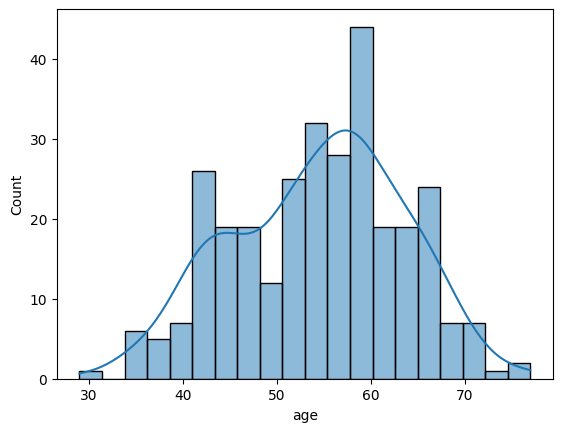

In [22]:
sns.histplot(df['age'],
             bins=20,
             kde=True,
             linewidth=1,
             edgecolor='k',
             kde_kws=dict(bw_adjust=1))
plt.show()

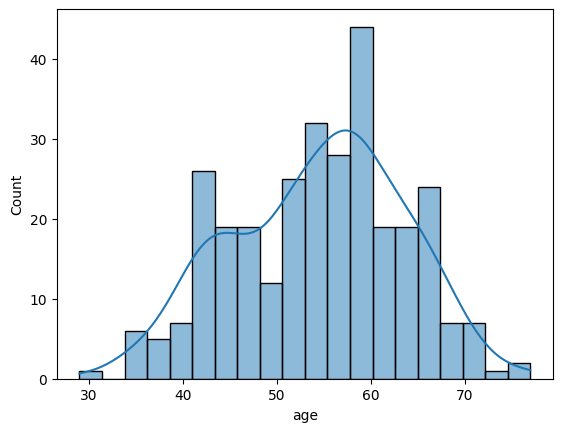

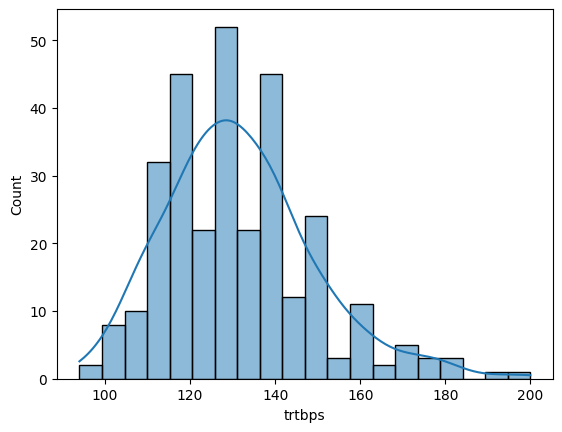

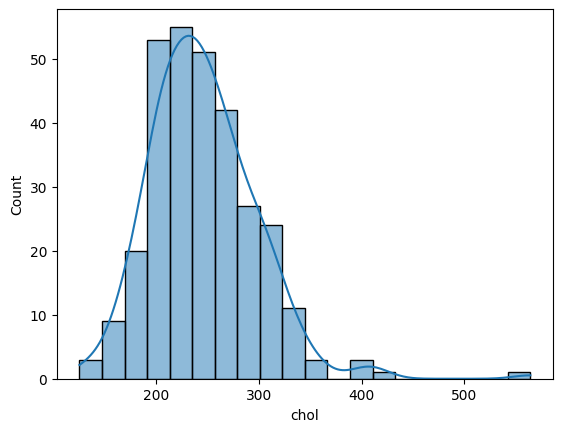

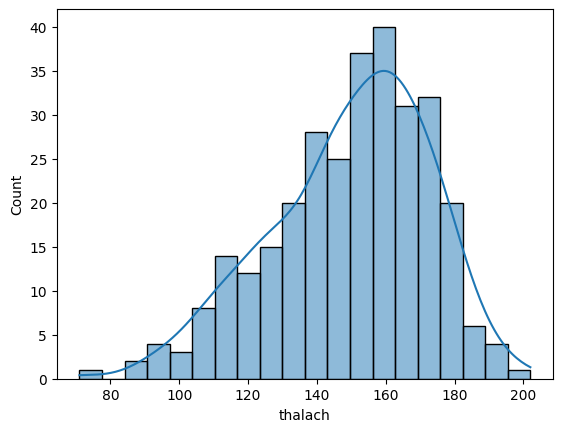

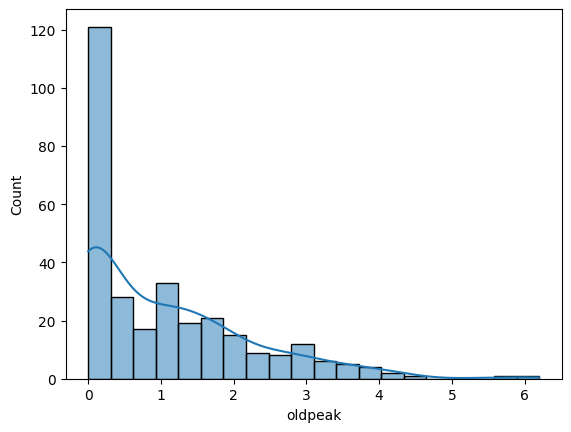

In [23]:
for i in numeric_var:
    sns.histplot(df[i],
             bins=20,
             kde=True,
             linewidth=1,
             edgecolor='k',
             kde_kws=dict(bw_adjust=1))
    plt.show()

In [24]:
# EDA (Uni-Variate Analysis) 
# categoric attributes

In [25]:
df["gender"].value_counts()

gender
1    207
0     96
Name: count, dtype: int64

In [26]:
total_observation_values=list(df["gender"].value_counts())

In [27]:
observation_value=list(df["gender"].value_counts().index)

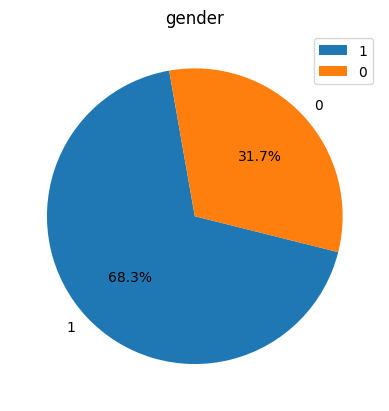

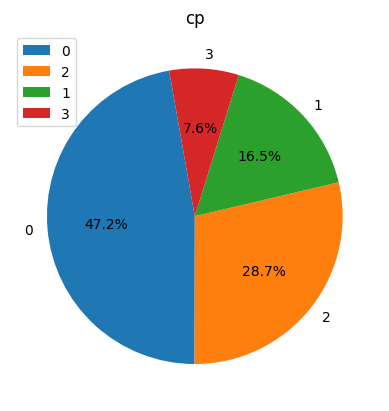

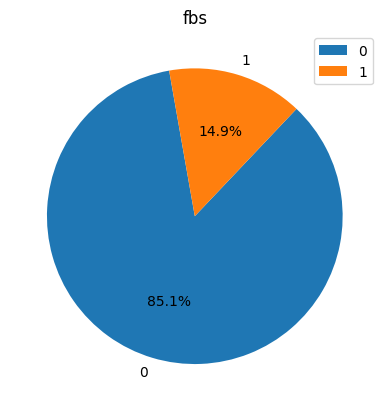

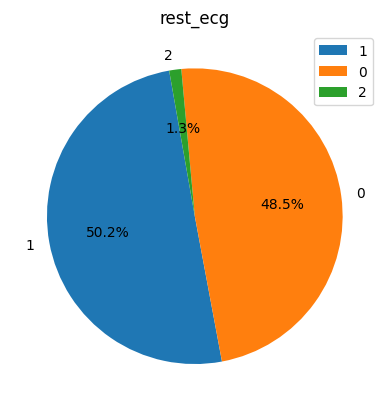

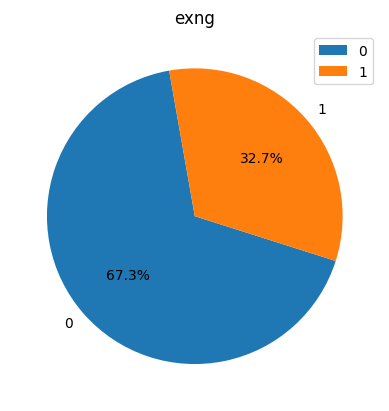

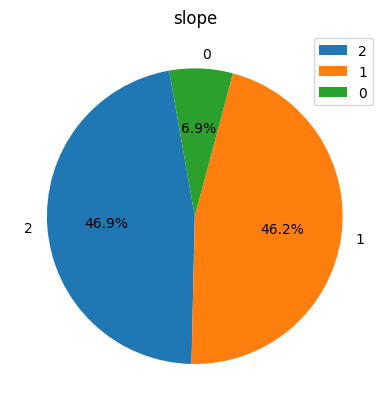

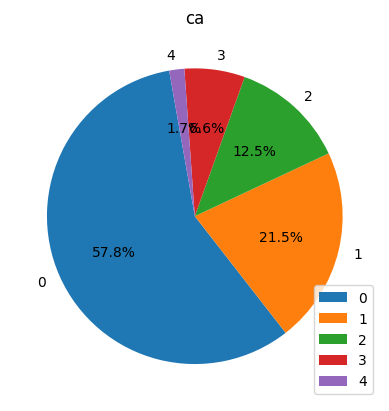

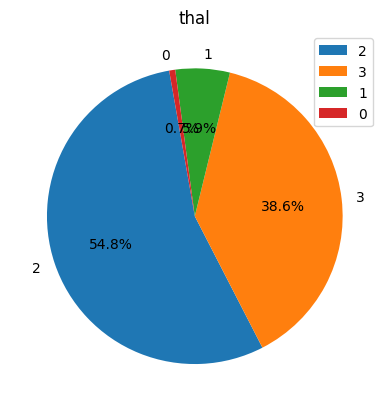

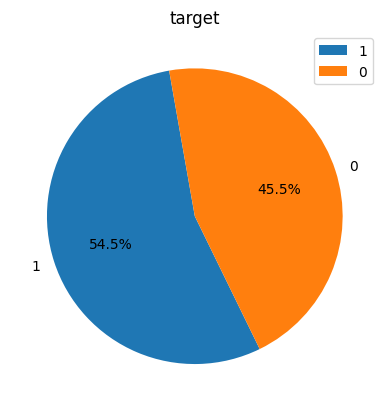

In [28]:
for i in categoric_var:  # ['gender', 'cp', 'fbs', 'rest_ecg', 'exng', 'slope', 'ca', 'thal', 'target']
    observation_values=list(df[i].value_counts().index)
    total_observation_values=list(df[i].value_counts())
    plt.pie(total_observation_values,
    labels=observation_values,
    autopct='%1.1f%%',
    startangle=100,
    labeldistance=1.1)
    plt.title(i)
    plt.legend()
    plt.show()


In [29]:
df["thal"]==0

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Name: thal, Length: 303, dtype: bool

In [30]:
df[df["thal"]==0] # filtering, revise it from numpy slides

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
46,52,1,0,128,204,1,1,156,1,1.0,1,0,0,0
281,53,0,2,128,216,0,0,115,0,0.0,2,0,0,1


In [31]:
df["thal"]=df["thal"].replace(0,2)

In [32]:
df[df["thal"]==0] # to check if the replace was done

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target


In [33]:
df.loc[[46,281],:]  # to check if the replace was done

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
46,52,1,0,128,204,1,1,156,1,1.0,1,0,2,0
281,53,0,2,128,216,0,0,115,0,0.0,2,0,2,1


In [34]:
df[df["ca"]==4]

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
40,52,1,2,138,223,0,1,169,0,0.0,2,4,2,1
45,43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
79,58,1,1,125,220,0,1,144,0,0.4,1,4,3,1
80,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
95,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


In [35]:
df["ca"]=df["ca"].replace(4,0)

In [36]:
df[df["ca"]==4]

,age,gender,cp,trtbps,chol,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target


In [37]:
# EDA (Bi-variate Analysis)
# Neumeric with the target analysis

In [38]:
numeric_var.append('target')
numeric_var

['age', 'trtbps', 'chol', 'thalach', 'oldpeak', 'target']

In [39]:
# ['age', 'trtbps', 'chol', 'thalach', 'oldpeak', 'target']
#    0       1         2         3          4        5
#len= 6
# [0:5]  i =0, 1 ,2, 3, 4


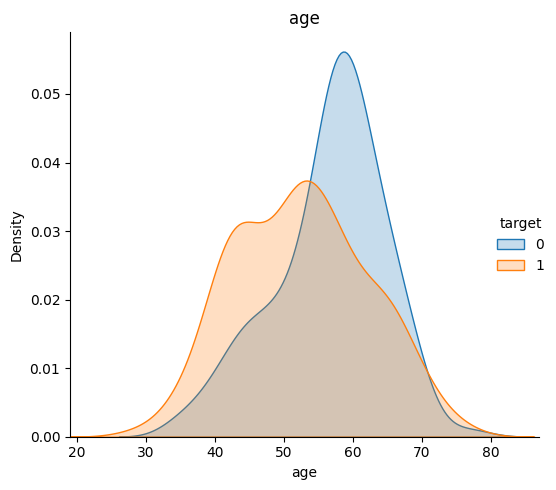

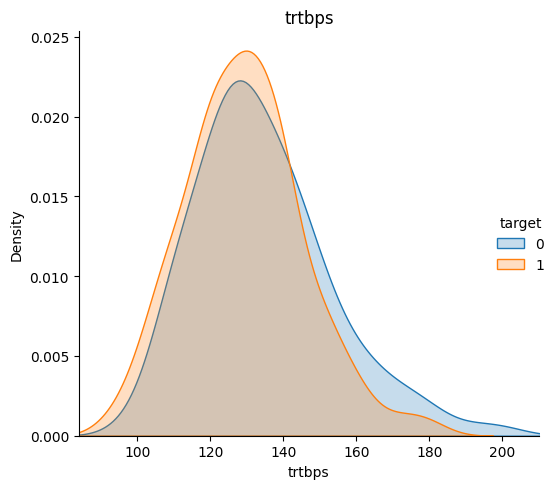

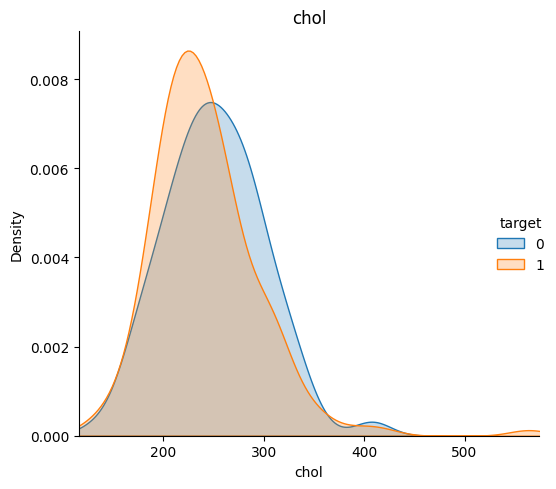

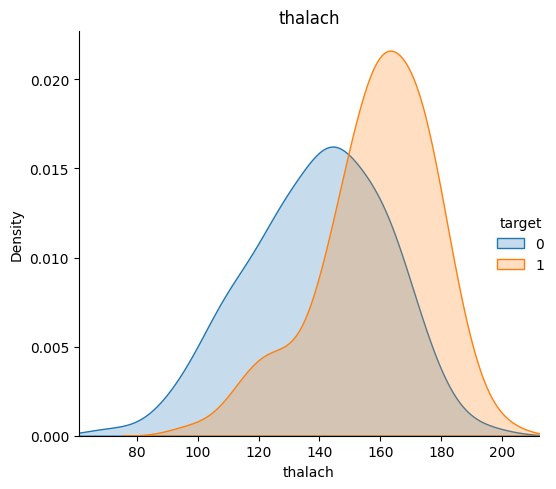

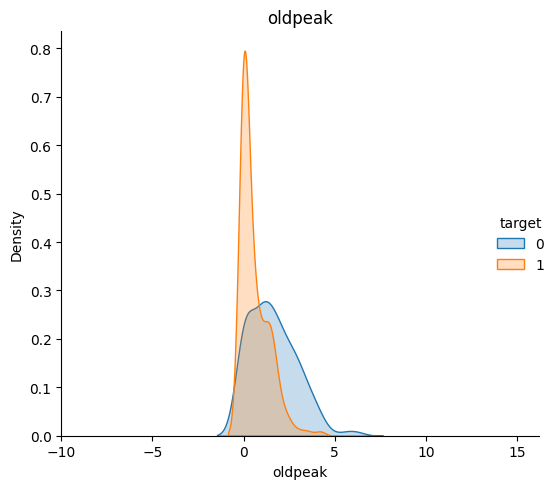

In [40]:
for i in numeric_var[0:len(numeric_var)-1]:
    graphs=sns.FacetGrid(df[numeric_var],
                         hue='target', # target= 1, 0
                         height=5,
                         xlim=((df[i].min()-10,
                                df[i].max()+10)))
    graphs.map(sns.kdeplot,i,fill=True)
    graphs.add_legend()
    plt.title(i)
    plt.tight_layout()
    plt.show()
                         

In [41]:
# if you want to draw for one variable
#graphs=sns.FacetGrid(df,
 #                        hue='target', # target= 1, 0
  #                       height=5,
   #                      xlim=((df["age"].min()-10,
    #                            df["age"].max()+10)))
#graphs.map(sns.kdeplot,"age",fill=True)
#graphs.add_legend()
#plt.title("age")
#plt.tight_layout()
#plt.show()

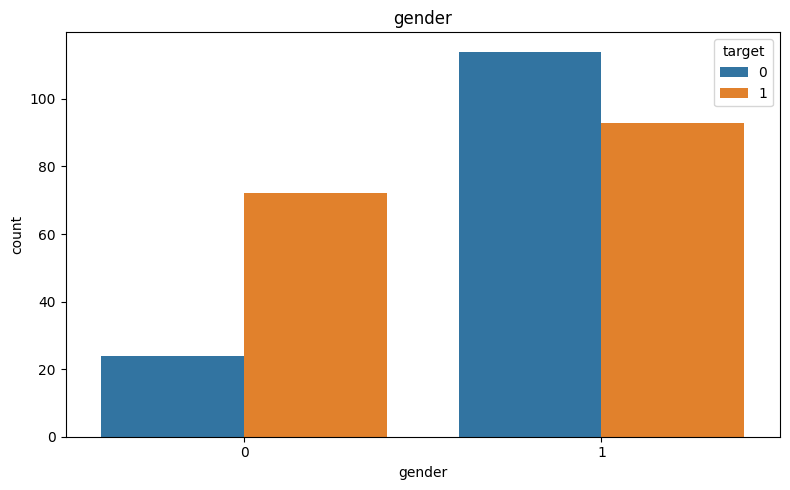

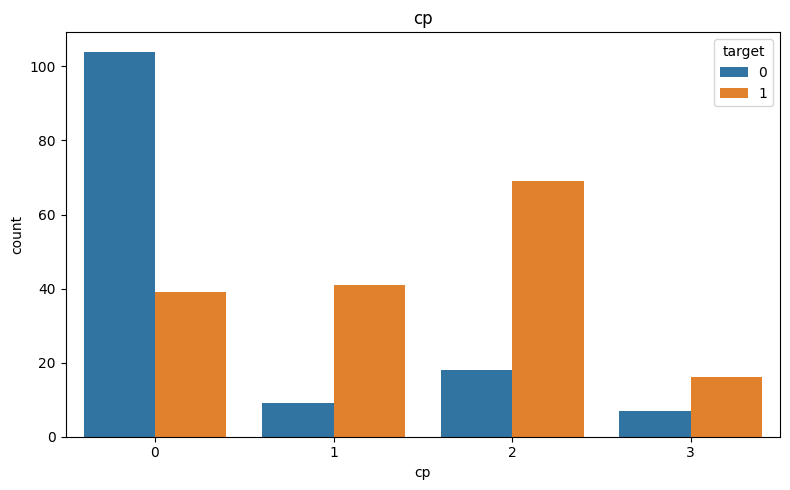

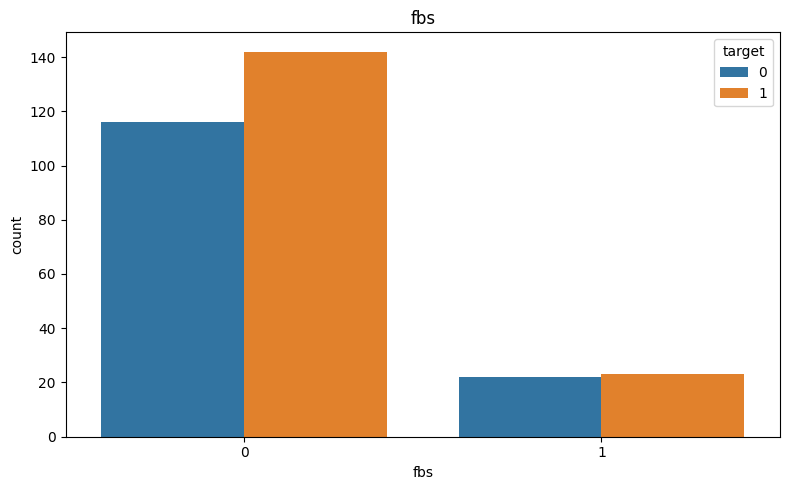

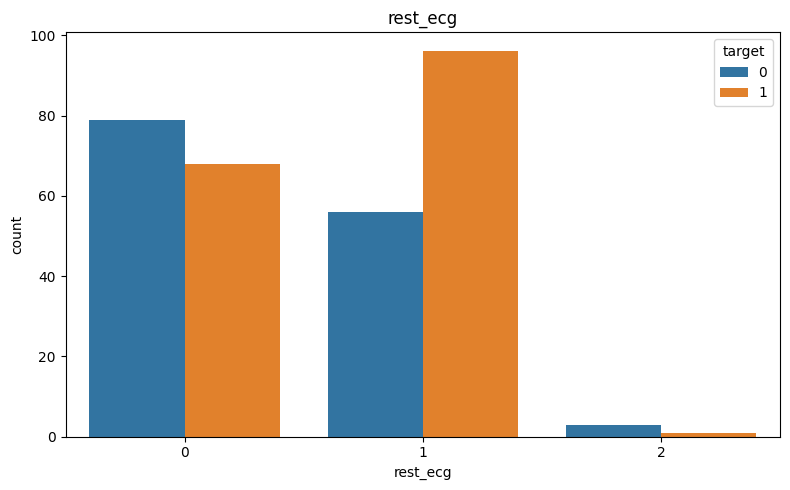

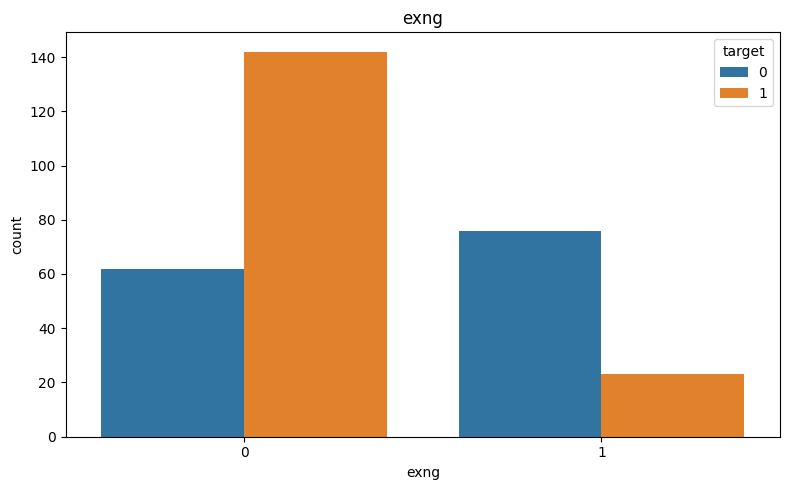

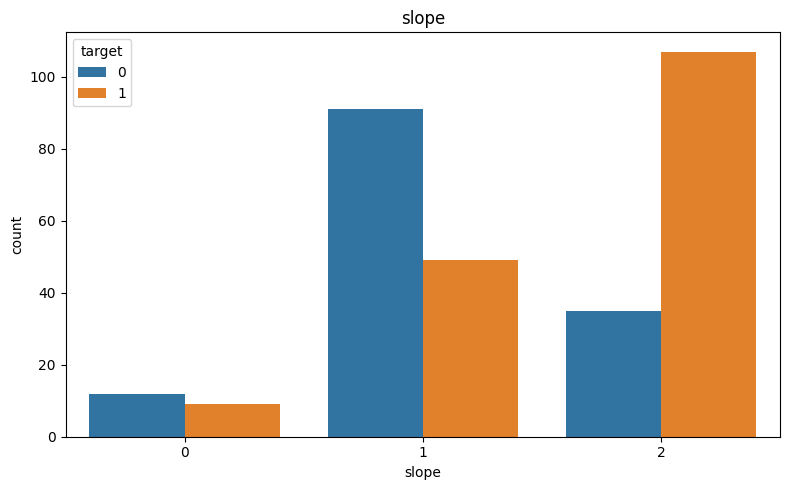

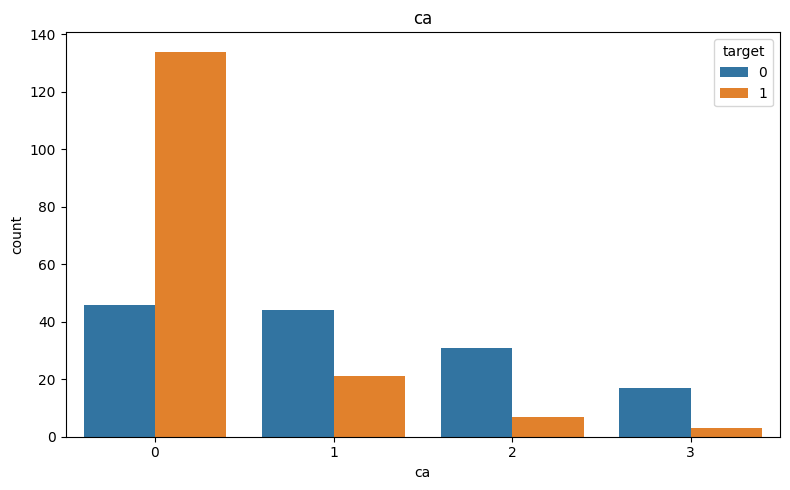

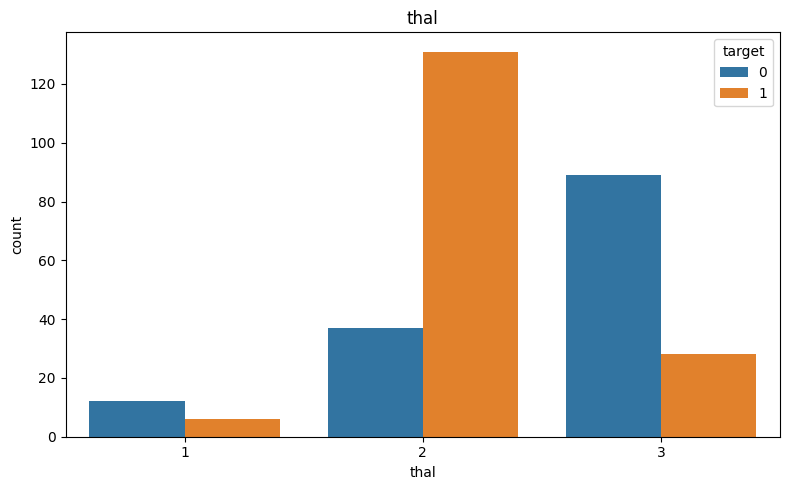

In [42]:
for i in categoric_var[0:len(categoric_var)-1]: 
#['gender', 'cp', 'fbs', 'rest_ecg', 'exng', 'slope', 'ca', 'thal', 'target']

    plt.figure(figsize=(8,5))
    sns.countplot(x=i,data=df[categoric_var],hue="target")
    plt.title(i)
    plt.tight_layout()
    plt.show()

In [43]:
numeric_var.remove("target")
numeric_var

['age', 'trtbps', 'chol', 'thalach', 'oldpeak']

In [44]:
from sklearn.preprocessing import RobustScaler
robust_scaler=RobustScaler() # object from RobustScaler class
scaled_data=robust_scaler.fit_transform(df[numeric_var])
scaled_data

array([[ 0.14814815,  1.        ,  0.56692913, -1.26153846, -0.125     ],
       [ 0.2962963 ,  2.        ,  0.75590551,  0.18461538, -0.375     ],
       [ 0.14814815,  1.        , -1.79527559,  0.61538462, -0.375     ],
       ...,
       [ 1.03703704,  1.5       , -0.09448819, -0.67692308, -0.4375    ],
       [-0.66666667, -0.5       ,  0.14173228, -0.27692308,  0.        ],
       [ 0.59259259,  0.5       , -0.70866142,  0.8       , -0.5       ]])

In [45]:
df_scaled=pd.DataFrame(scaled_data,columns=numeric_var)
df_scaled

,age,trtbps,chol,thalach,oldpeak
0,0.148148,1.0,0.566929,-1.261538,-0.1250
1,0.296296,2.0,0.755906,0.184615,-0.3750
2,0.148148,1.0,-1.795276,0.615385,-0.3750
3,0.074074,0.2,2.661417,-0.092308,0.6875
4,1.185185,-1.0,0.393701,-0.707692,-0.5000
...,...,...,...,...,...
298,-0.370370,0.5,-0.110236,0.307692,-0.1250
299,-0.296296,-1.8,-0.204724,0.030769,-0.5000
300,1.037037,1.5,-0.094488,-0.676923,-0.4375
301,-0.666667,-0.5,0.141732,-0.276923,0.0000


In [46]:
df_new=pd.concat([df_scaled,df.loc[:,'target']],axis=1)
df_new

,age,trtbps,chol,thalach,oldpeak,target
0,0.148148,1.0,0.566929,-1.261538,-0.1250,0
1,0.296296,2.0,0.755906,0.184615,-0.3750,0
2,0.148148,1.0,-1.795276,0.615385,-0.3750,1
3,0.074074,0.2,2.661417,-0.092308,0.6875,0
4,1.185185,-1.0,0.393701,-0.707692,-0.5000,1
...,...,...,...,...,...,...
298,-0.370370,0.5,-0.110236,0.307692,-0.1250,0
299,-0.296296,-1.8,-0.204724,0.030769,-0.5000,1
300,1.037037,1.5,-0.094488,-0.676923,-0.4375,1
301,-0.666667,-0.5,0.141732,-0.276923,0.0000,0


In [47]:
melted_data=pd.melt(df_new,id_vars="target",
                    var_name="variables",
                    value_name="value")
melted_data

,target,variables,value
0,0,age,0.148148
1,0,age,0.296296
2,1,age,0.148148
3,0,age,0.074074
4,1,age,1.185185
...,...,...,...
1510,0,oldpeak,-0.125000
1511,1,oldpeak,-0.500000
1512,1,oldpeak,-0.437500
1513,0,oldpeak,0.000000


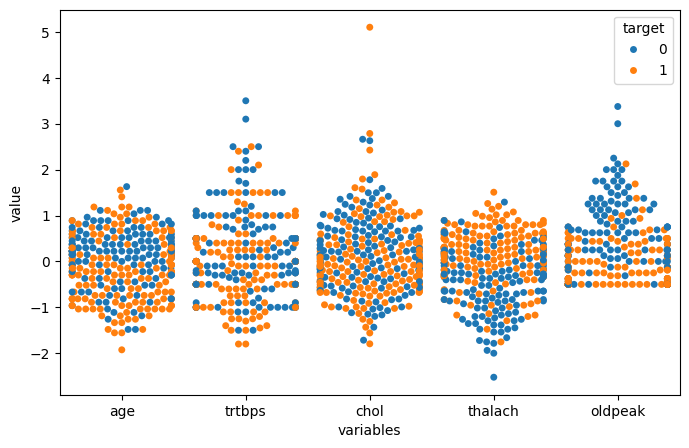

In [48]:
plt.figure(figsize=(8,5))
sns.swarmplot(x="variables",
              y="value",
              hue="target",
              data=melted_data)
plt.show()

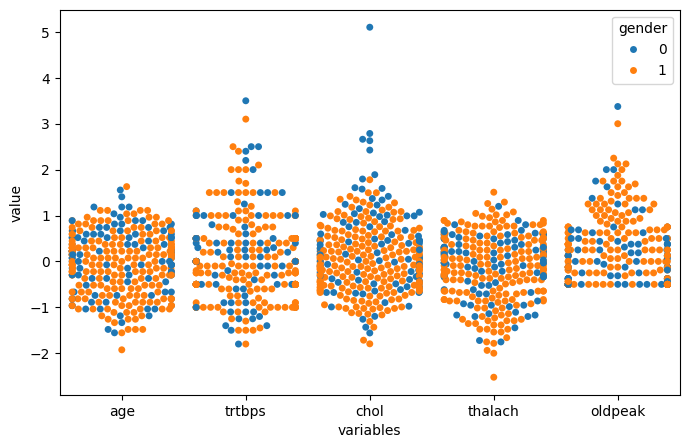

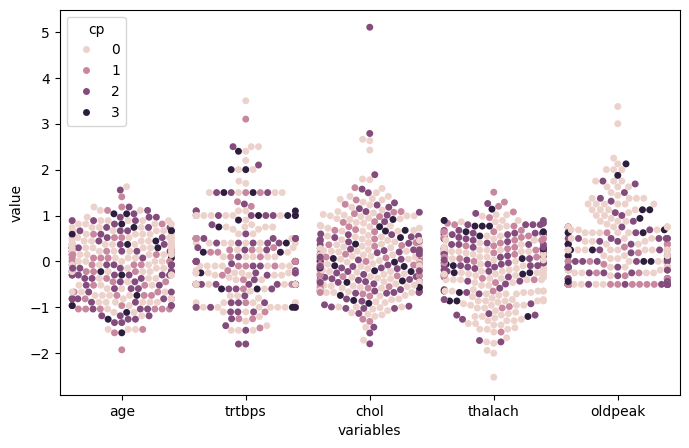

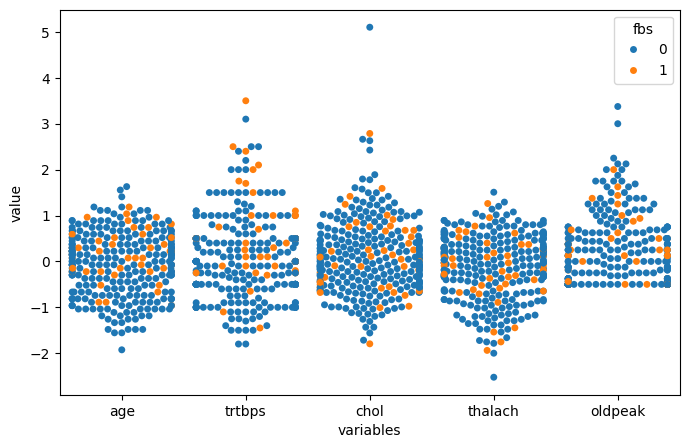

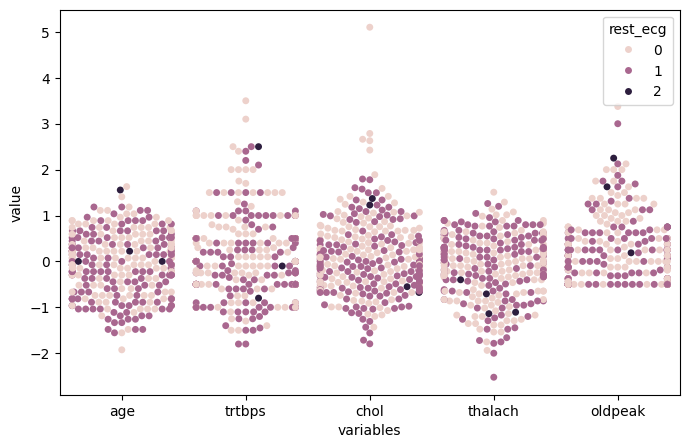

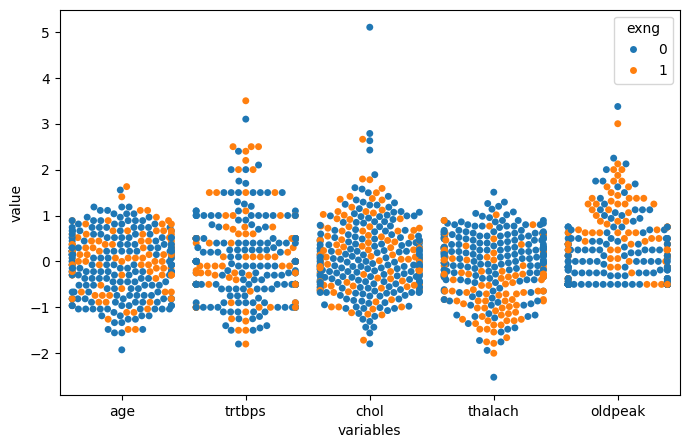

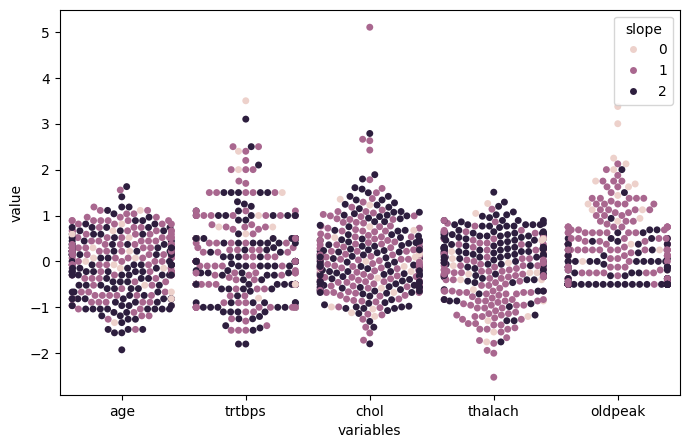

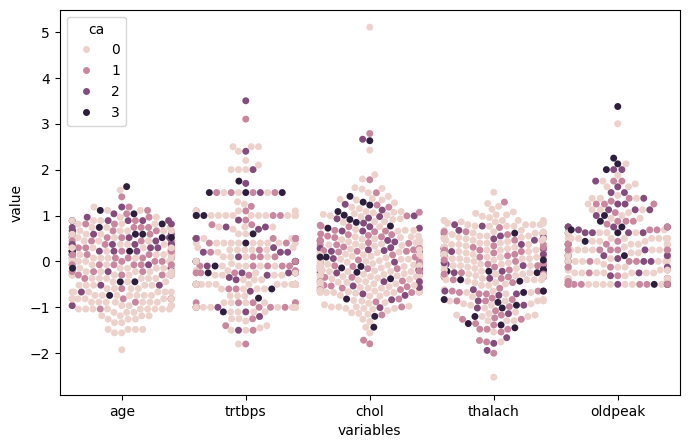

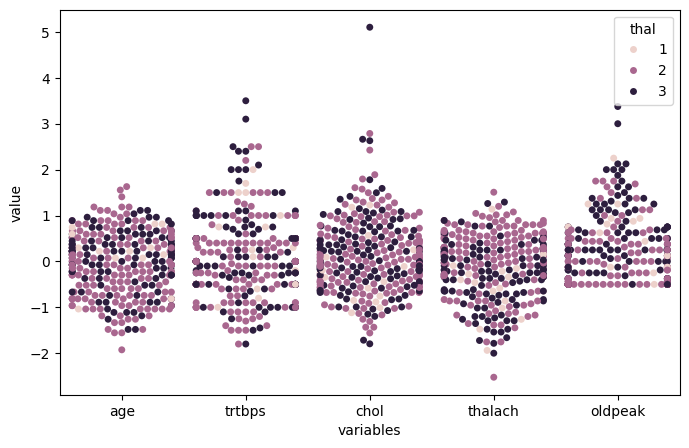

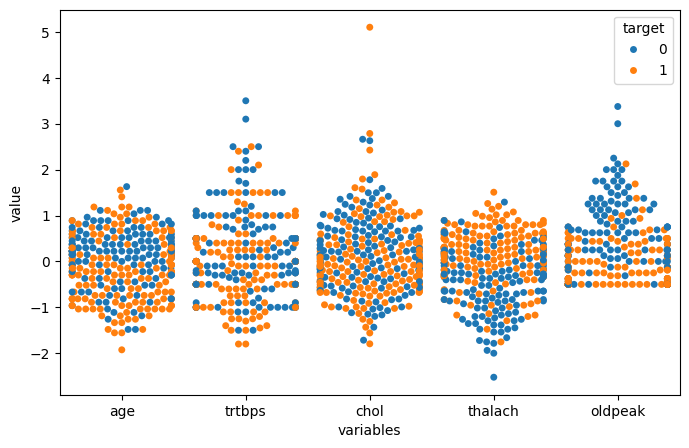

In [49]:
for i in categoric_var: 
    # ['gender', 'cp', 'fbs', 'rest_ecg', 'exng', 'slope', 'ca', 'thal', 'target']

    df_new=pd.concat([df_scaled,df.loc[:,i]],axis=1)
    melted_data=pd.melt(df_new,id_vars=i,
                    var_name="variables",
                    value_name="value")
    
    plt.figure(figsize=(8,5))
    sns.swarmplot(x="variables",
              y="value",
              hue=i,
              data=melted_data)
    plt.show()

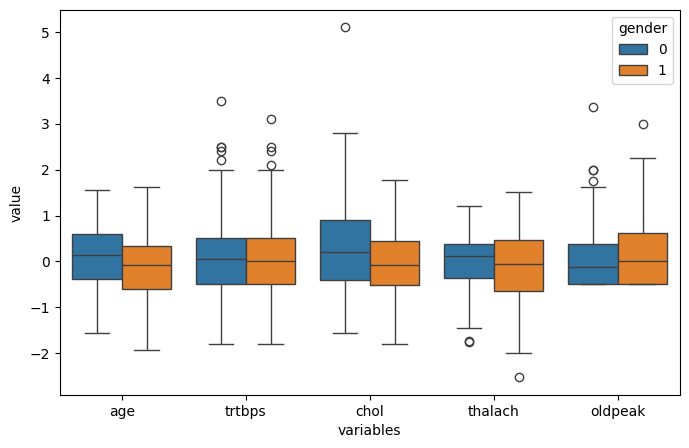

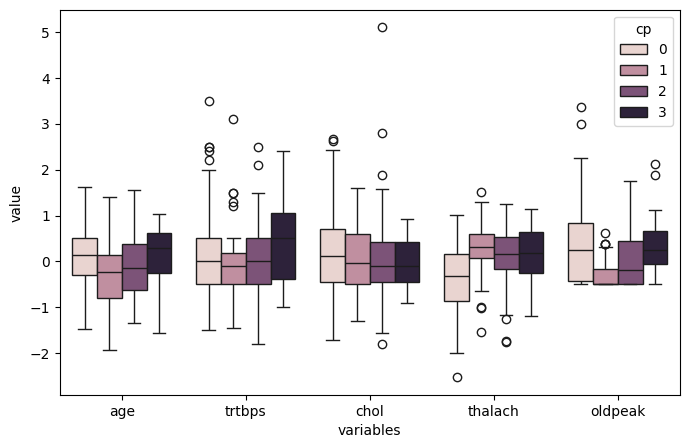

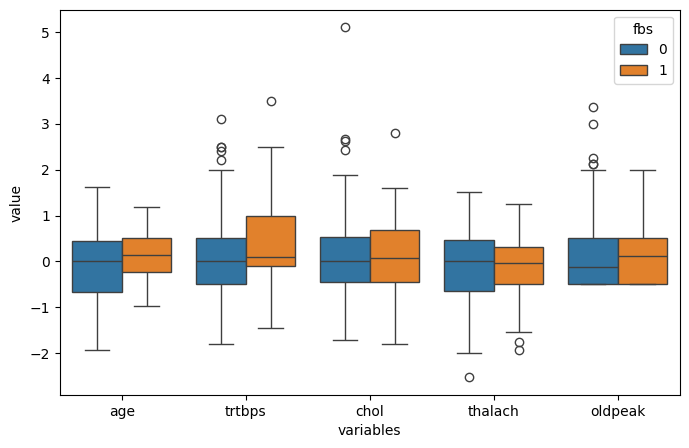

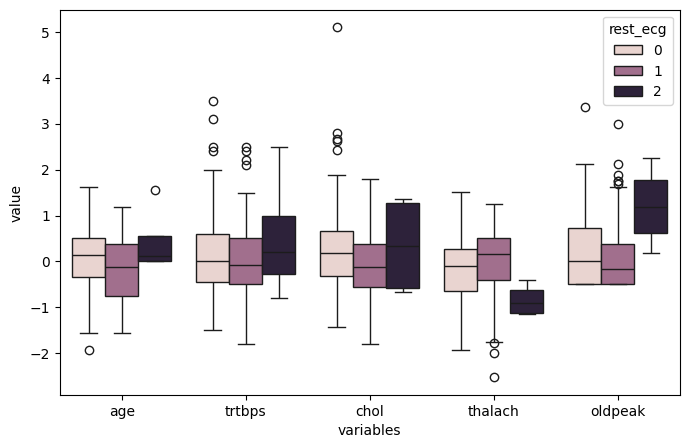

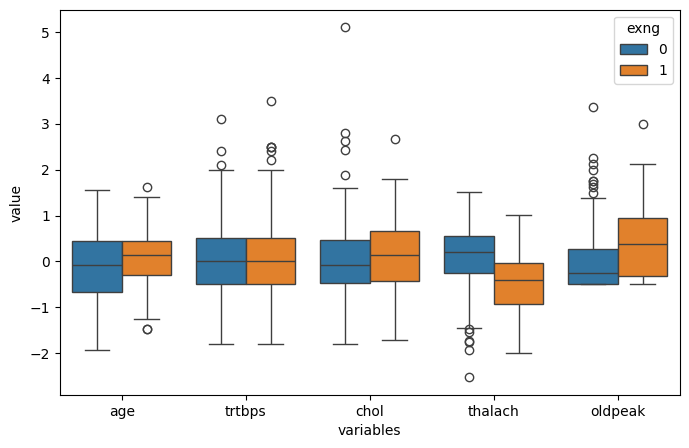

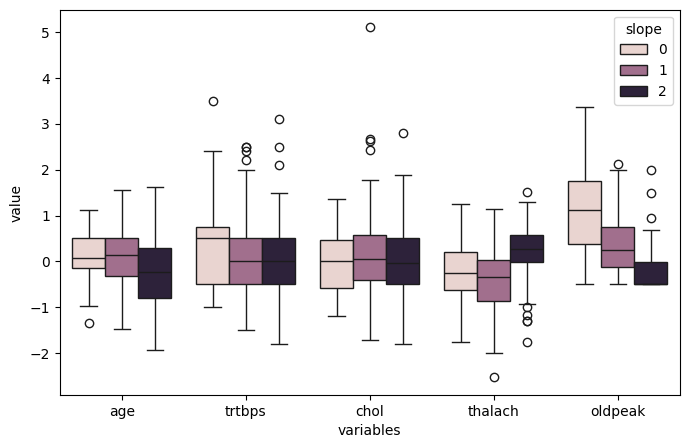

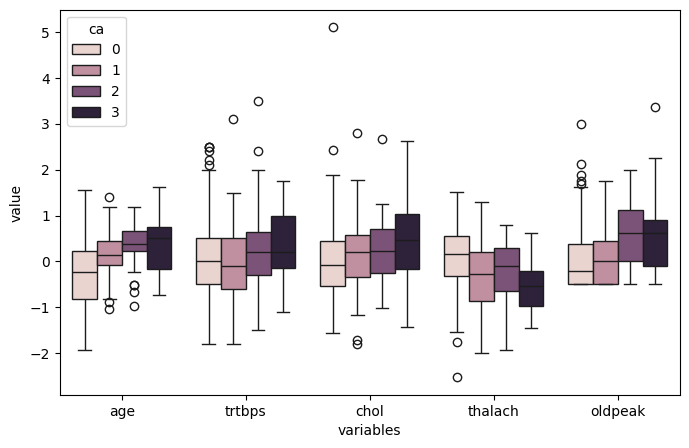

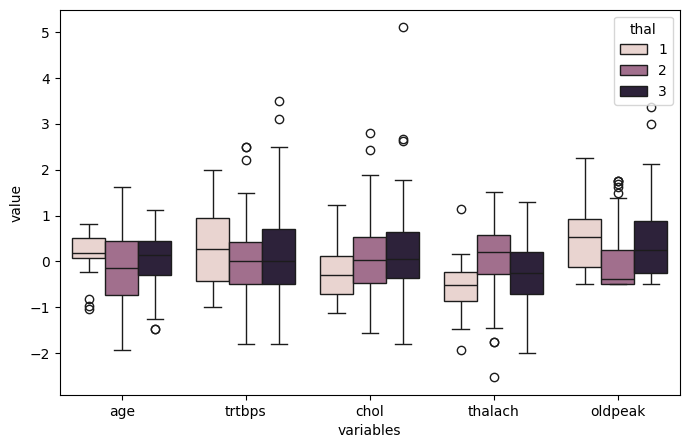

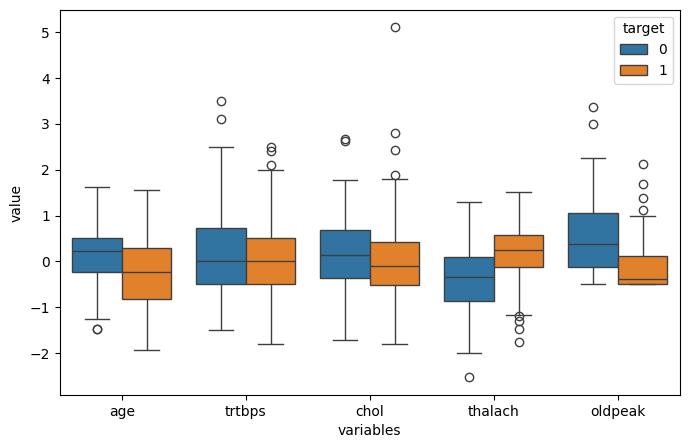

In [50]:
for i in categoric_var: 
    # ['gender', 'cp', 'fbs', 'rest_ecg', 'exng', 'slope', 'ca', 'thal', 'target']

    df_new=pd.concat([df_scaled,df.loc[:,i]],axis=1)
    melted_data=pd.melt(df_new,id_vars=i,
                    var_name="variables",
                    value_name="value")
    
    plt.figure(figsize=(8,5))
    sns.boxplot(x="variables",
              y="value",
              hue=i,
              data=melted_data)
    plt.show()

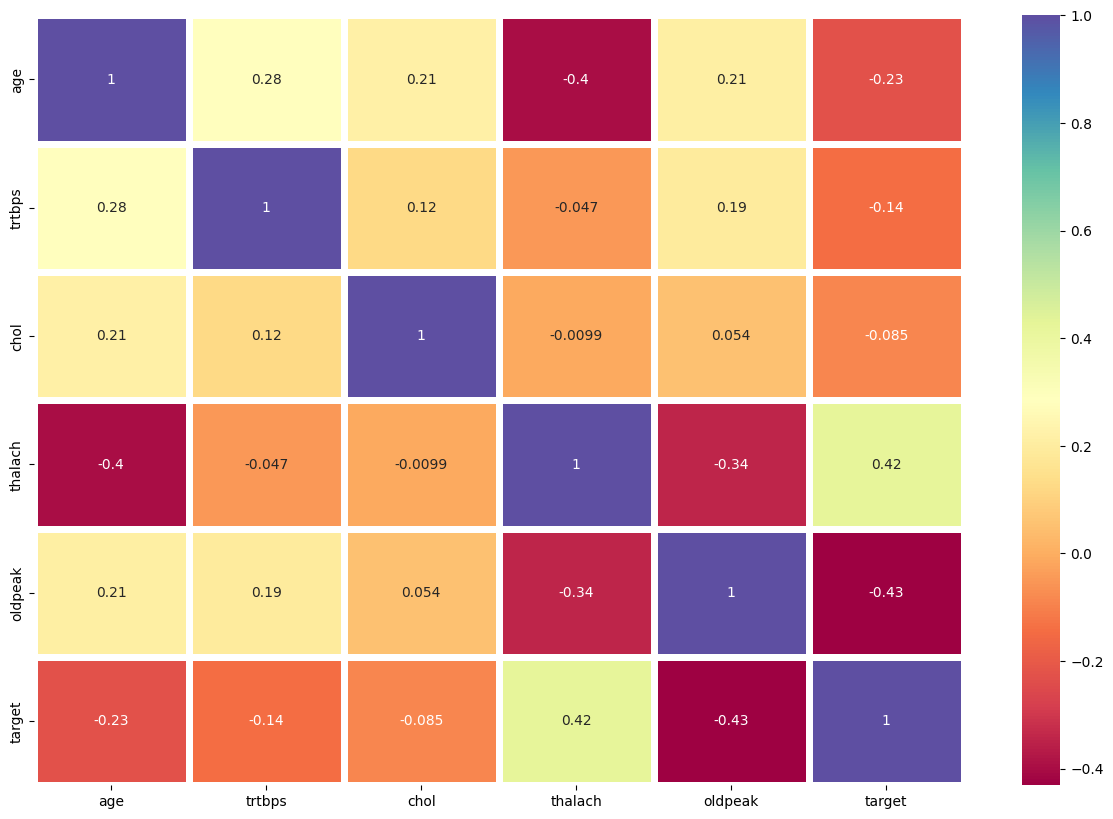

In [51]:
df_new2=pd.concat([df_scaled,df["target"]],axis=1)
plt.figure(figsize=(15,10))
sns.heatmap(data=df_new2.corr(), 
            cmap="Spectral",
            annot=True,
            linewidths=5)
plt.show()

In [52]:
df.drop(["chol"],axis=1,inplace=True)
df

,age,gender,cp,trtbps,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
0,57,1,0,150,0,0,112,1,0.6,1,1,1,0
1,59,1,3,170,0,0,159,0,0.2,1,0,3,0
2,57,1,2,150,1,1,173,0,0.2,2,1,3,1
3,56,0,0,134,0,0,150,1,1.9,1,2,3,0
4,71,0,2,110,1,0,130,0,0.0,2,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,0,1,163,0,0.6,1,1,3,0
299,51,1,2,94,0,1,154,1,0.0,2,1,3,1
300,69,1,3,160,1,0,131,0,0.1,1,1,2,1
301,46,1,0,120,0,0,144,0,0.8,2,0,3,0


In [53]:
numeric_var.remove("chol")
numeric_var

['age', 'trtbps', 'thalach', 'oldpeak']

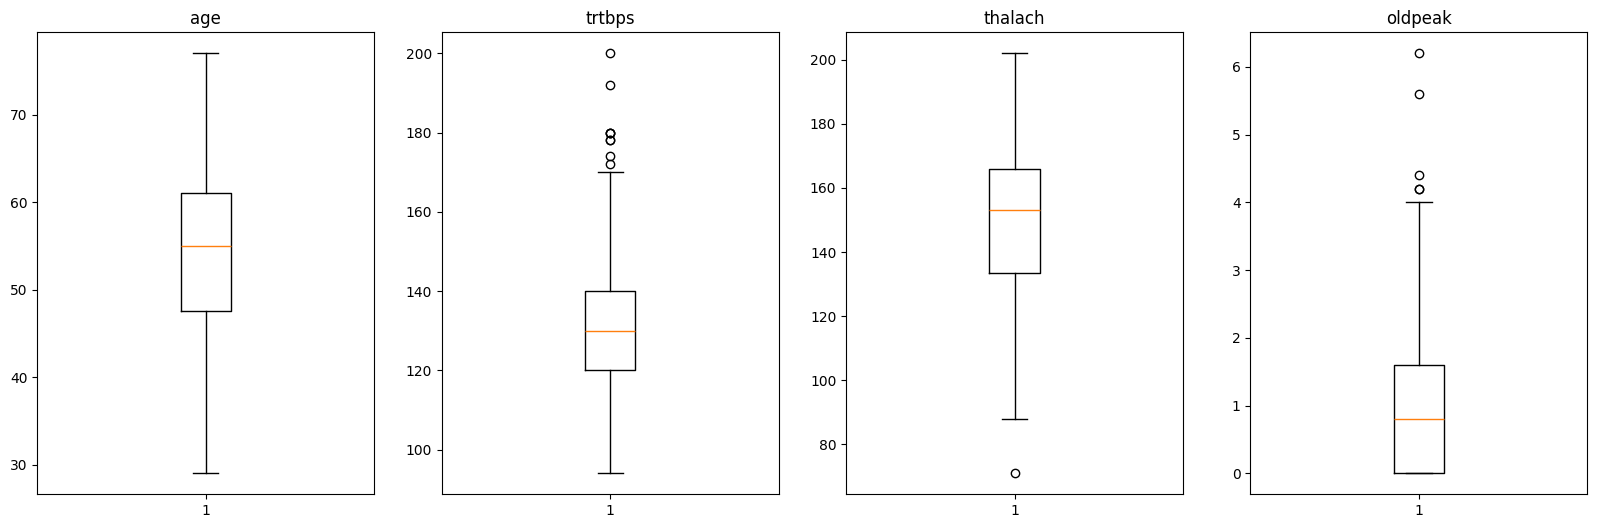

In [54]:
#data clearningabs
# outliers detection
fig, (ax1,ax2,ax3,ax4)=plt.subplots(1,4,figsize=(20,6))
# x,y=3,4
ax1.boxplot(df["age"])
ax1.set_title("age")

ax2.boxplot(df["trtbps"])
ax2.set_title("trtbps")

ax3.boxplot(df["thalach"])
ax3.set_title("thalach")

ax4.boxplot(df["oldpeak"])
ax4.set_title("oldpeak")

plt.show()

In [55]:
df[["age","trtbps","thalach","oldpeak"]].agg(["skew"]).transpose()

,skew
age,-0.202463
trtbps,0.713768
thalach,-0.537410
oldpeak,1.269720


In [56]:
# minnormal_value= q1-1.5*IQR
# IQR=Q3-Q1
#maxnormal_value=q3+1.5*IQR
from scipy import stats
from scipy.stats import zscore
from scipy.stats.mstats import winsorize
def iqr(df, var):
    q1 = np.quantile(df[var], 0.25)
    q3 = np.quantile(df[var], 0.75)
    IQR = q3 - q1
    lower_v = q1 - (1.5 * IQR)
    upper_v = q3 + (1.5 * IQR)
    return df[(df[var] < lower_v) | (df[var] > upper_v)]

In [57]:
iqr(df,"oldpeak")

,age,gender,cp,trtbps,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target
11,59,1,3,178,0,0,145,0,4.2,0,0,3,1
55,62,0,0,160,0,0,145,0,6.2,0,3,3,0
86,51,1,0,140,0,1,122,1,4.2,1,3,3,0
103,58,1,0,114,0,2,140,0,4.4,0,3,1,0
160,55,1,0,140,0,1,111,1,5.6,0,0,3,0


In [58]:
min_outlier=iqr(df,"oldpeak").oldpeak.min()
min_outlier

4.2

In [59]:
max_normal_value=df[df["oldpeak"]<min_outlier].oldpeak.max()
max_normal_value

4.0

In [60]:
percntile_oldpeak=(stats.percentileofscore(df["oldpeak"],max_normal_value))/100
percntile_oldpeak

0.9801980198019803

In [61]:
upper_limit=1-percntile_oldpeak
upper_limit

0.01980198019801971

In [62]:
oldpeak_winzorize=winsorize(df.oldpeak,(0,upper_limit))

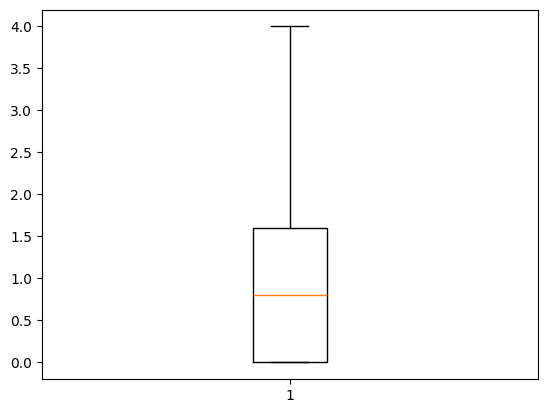

In [63]:
plt.boxplot(oldpeak_winzorize)
plt.show()

In [64]:
df["oldpeak_winzorize"]=oldpeak_winzorize
df

,age,gender,cp,trtbps,fbs,rest_ecg,thalach,exng,oldpeak,slope,ca,thal,target,oldpeak_winzorize
0,57,1,0,150,0,0,112,1,0.6,1,1,1,0,0.6
1,59,1,3,170,0,0,159,0,0.2,1,0,3,0,0.2
2,57,1,2,150,1,1,173,0,0.2,2,1,3,1,0.2
3,56,0,0,134,0,0,150,1,1.9,1,2,3,0,1.9
4,71,0,2,110,1,0,130,0,0.0,2,1,2,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,0,1,163,0,0.6,1,1,3,0,0.6
299,51,1,2,94,0,1,154,1,0.0,2,1,3,1,0.0
300,69,1,3,160,1,0,131,0,0.1,1,1,2,1,0.1
301,46,1,0,120,0,0,144,0,0.8,2,0,3,0,0.8


In [65]:
df.drop(["oldpeak"],axis=1,inplace=True)
df

,age,gender,cp,trtbps,fbs,rest_ecg,thalach,exng,slope,ca,thal,target,oldpeak_winzorize
0,57,1,0,150,0,0,112,1,1,1,1,0,0.6
1,59,1,3,170,0,0,159,0,1,0,3,0,0.2
2,57,1,2,150,1,1,173,0,2,1,3,1,0.2
3,56,0,0,134,0,0,150,1,1,2,3,0,1.9
4,71,0,2,110,1,0,130,0,2,1,2,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,0,1,163,0,1,1,3,0,0.6
299,51,1,2,94,0,1,154,1,2,1,3,1,0.0
300,69,1,3,160,1,0,131,0,1,1,2,1,0.1
301,46,1,0,120,0,0,144,0,2,0,3,0,0.8


In [66]:
df["trtbps"]


0      150
1      170
2      150
3      134
4      110
      ... 
298    140
299     94
300    160
301    120
302    140
Name: trtbps, Length: 303, dtype: int64

In [67]:
z_trtpbs=zscore(df["trtbps"])
z_trtpbs

0      1.049520
1      2.191778
2      1.049520
3      0.135714
4     -1.234996
         ...   
298    0.478391
299   -2.148802
300    1.620649
301   -0.663867
302    0.478391
Name: trtbps, Length: 303, dtype: float64

In [68]:
for i in range(1,4):
     print(f"threshold {i}")
     print(f"outliers {len(np.where(z_trtpbs>i)[0])}")


threshold 1
outliers 51
threshold 2
outliers 13
threshold 3
outliers 2


In [69]:
# threshold =2
min_outlier=df[z_trtpbs>2].trtbps.min()
min_outlier

170

In [70]:
max_normal_value=df[df["trtbps"]<min_outlier].trtbps.max()
max_normal_value

165

In [71]:
percntile_trtbps=(stats.percentileofscore(df["trtbps"],max_normal_value))/100
percntile_trtbps

0.957095709570957

In [72]:
upper_limit=1-percntile_trtbps
upper_limit

0.04290429042904298

In [73]:
trtbps_winzorize=winsorize(df.trtbps,(0,upper_limit))

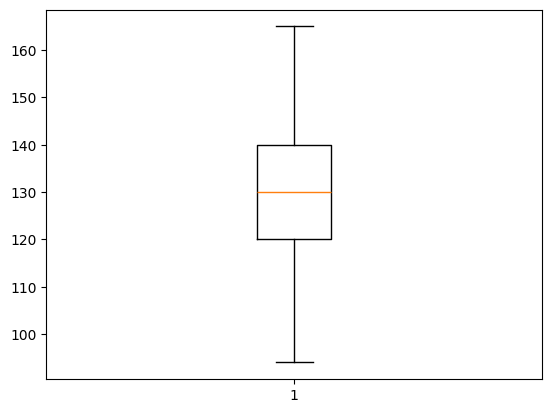

In [74]:
plt.boxplot(trtbps_winzorize)
plt.show()

In [75]:
df["trtbps_winzorize"]=trtbps_winzorize
df

,age,gender,cp,trtbps,fbs,rest_ecg,thalach,exng,slope,ca,thal,target,oldpeak_winzorize,trtbps_winzorize
0,57,1,0,150,0,0,112,1,1,1,1,0,0.6,150
1,59,1,3,170,0,0,159,0,1,0,3,0,0.2,165
2,57,1,2,150,1,1,173,0,2,1,3,1,0.2,150
3,56,0,0,134,0,0,150,1,1,2,3,0,1.9,134
4,71,0,2,110,1,0,130,0,2,1,2,1,0.0,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,140,0,1,163,0,1,1,3,0,0.6,140
299,51,1,2,94,0,1,154,1,2,1,3,1,0.0,94
300,69,1,3,160,1,0,131,0,1,1,2,1,0.1,160
301,46,1,0,120,0,0,144,0,2,0,3,0,0.8,120


In [76]:
df.drop(["trtbps"],axis=1,inplace=True)
df

,age,gender,cp,fbs,rest_ecg,thalach,exng,slope,ca,thal,target,oldpeak_winzorize,trtbps_winzorize
0,57,1,0,0,0,112,1,1,1,1,0,0.6,150
1,59,1,3,0,0,159,0,1,0,3,0,0.2,165
2,57,1,2,1,1,173,0,2,1,3,1,0.2,150
3,56,0,0,0,0,150,1,1,2,3,0,1.9,134
4,71,0,2,1,0,130,0,2,1,2,1,0.0,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,0,1,163,0,1,1,3,0,0.6,140
299,51,1,2,0,1,154,1,2,1,3,1,0.0,94
300,69,1,3,1,0,131,0,1,1,2,1,0.1,160
301,46,1,0,0,0,144,0,2,0,3,0,0.8,120


In [77]:
z_thalach=zscore(df["thalach"])
for i in range(1,4):
     print(f"threshold {i}")
     print(f"outliers {len(np.where(z_thalach>i)[0])}")

threshold 1
outliers 47
threshold 2
outliers 1
threshold 3
outliers 0


In [78]:
#min_outlier=df[z_thalach>2].thalach.min()
#max_normal_value=df[df["thalach"]<min_outlier].thalach.max()
#percntile_thalach=(stats.percentileofscore(df["thalach"],max_normal_value))/100
#upper_limit=1-percntile_thalach
#thalach_winzorize=winsorize(df.thalach,(upper_limit,0))
#plt.boxplot(thalach_winzorize)
#plt.show()

In [79]:
#df[z_thalach>2][["thalach"]]

In [80]:
#df.drop([92],axis=0,inplace=True)
#plt.boxplot(df["thalach"])
#plt.show()

In [81]:
iqr(df, "thalach")[["thalach"]]

,thalach
22,71


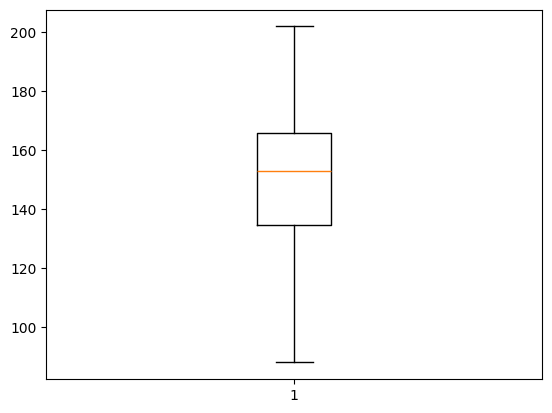

In [82]:
df.drop([22],axis=0,inplace=True)
plt.boxplot(df["thalach"])
plt.show()

In [83]:
df

,age,gender,cp,fbs,rest_ecg,thalach,exng,slope,ca,thal,target,oldpeak_winzorize,trtbps_winzorize
0,57,1,0,0,0,112,1,1,1,1,0,0.6,150
1,59,1,3,0,0,159,0,1,0,3,0,0.2,165
2,57,1,2,1,1,173,0,2,1,3,1,0.2,150
3,56,0,0,0,0,150,1,1,2,3,0,1.9,134
4,71,0,2,1,0,130,0,2,1,2,1,0.0,110
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,0,1,163,0,1,1,3,0,0.6,140
299,51,1,2,0,1,154,1,2,1,3,1,0.0,94
300,69,1,3,1,0,131,0,1,1,2,1,0.1,160
301,46,1,0,0,0,144,0,2,0,3,0,0.8,120


In [84]:
# transformation
df[["age","trtbps_winzorize","thalach","oldpeak_winzorize"]].agg(["skew"]).transpose()

,skew
age,-0.199209
trtbps_winzorize,0.251969
thalach,-0.461611
oldpeak_winzorize,0.996036


In [85]:
df["oldpeak_winsorize_log"]=np.log(df["oldpeak_winzorize"])
df["oldpeak_winsorize_sqrt"]=np.sqrt(df["oldpeak_winzorize"])



In [86]:
df[["oldpeak_winsorize_log","oldpeak_winsorize_sqrt"]].agg(["skew"]).transpose()

,skew
oldpeak_winsorize_log,NaN
oldpeak_winsorize_sqrt,0.108926


In [87]:
df.drop(["oldpeak_winsorize_log","oldpeak_winzorize"],axis=1,inplace=True)
df

,age,gender,cp,fbs,rest_ecg,thalach,exng,slope,ca,thal,target,trtbps_winzorize,oldpeak_winsorize_sqrt
0,57,1,0,0,0,112,1,1,1,1,0,150,0.774597
1,59,1,3,0,0,159,0,1,0,3,0,165,0.447214
2,57,1,2,1,1,173,0,2,1,3,1,150,0.447214
3,56,0,0,0,0,150,1,1,2,3,0,134,1.378405
4,71,0,2,1,0,130,0,2,1,2,1,110,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,50,1,2,0,1,163,0,1,1,3,0,140,0.774597
299,51,1,2,0,1,154,1,2,1,3,1,94,0.000000
300,69,1,3,1,0,131,0,1,1,2,1,160,0.316228
301,46,1,0,0,0,144,0,2,0,3,0,120,0.894427


In [88]:
# One hot encoding

In [89]:
df_copy=df.copy()
df_copy = pd.get_dummies(df_copy, columns = categoric_var[:-1], drop_first = True)
pd.set_option('display.max_columns',None)
df_copy.head()

,age,thalach,target,trtbps_winzorize,oldpeak_winsorize_sqrt,gender_1,cp_1,cp_2,cp_3,fbs_1,rest_ecg_1,rest_ecg_2,exng_1,slope_1,slope_2,ca_1,ca_2,ca_3,thal_2,thal_3
0,57,112,0,150,0.774597,True,False,False,False,False,False,False,True,True,False,True,False,False,False,False
1,59,159,0,165,0.447214,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True
2,57,173,1,150,0.447214,True,False,True,False,True,True,False,False,False,True,True,False,False,False,True
3,56,150,0,134,1.378405,False,False,False,False,False,False,False,True,True,False,False,True,False,False,True
4,71,130,1,110,0.000000,False,False,True,False,True,False,False,False,False,True,True,False,False,True,False


In [90]:
# feature scaling

In [91]:
new_numeric_var=["age","thalach","trtbps_winzorize","oldpeak_winsorize_sqrt"]
robust_scaler=RobustScaler()
df_copy[new_numeric_var]=robust_scaler.fit_transform(df_copy[new_numeric_var])
df_copy.head()

,age,thalach,target,trtbps_winzorize,oldpeak_winsorize_sqrt,gender_1,cp_1,cp_2,cp_3,fbs_1,rest_ecg_1,rest_ecg_2,exng_1,slope_1,slope_2,ca_1,ca_2,ca_3,thal_2,thal_3
0,0.145455,-1.301587,0,1.00,-0.094734,True,False,False,False,False,False,False,True,True,False,True,False,False,False,False
1,0.290909,0.190476,0,1.75,-0.353553,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True
2,0.145455,0.634921,1,1.00,-0.353553,True,False,True,False,True,True,False,False,False,True,True,False,False,False,True
3,0.072727,-0.095238,0,0.20,0.382618,False,False,False,False,False,False,False,True,True,False,False,True,False,False,True
4,1.163636,-0.730159,1,-1.00,-0.707107,False,False,True,False,True,False,False,False,False,True,True,False,False,True,False


In [111]:
# Splitting data into training and testing
from sklearn.model_selection import train_test_split,StratifiedKFold
attributes=df_copy.drop(["target"],axis=1)
target=df_copy[["target"]]
attributes_train,attributes_test,target_train,target_test=train_test_split(attributes,
                                                                           target,test_size=0.1,
                                                                        random_state=3,
                                                                           stratify=target)
print(f"attributes_train={attributes_train.shape[0]}")
print(f"attributes_test={attributes_test.shape[0]}")
print(f"target_train={target_train.shape[0]}")
print(f"target_test={target_test.shape[0]}")


attributes_train=271
attributes_test=31
target_train=271
target_test=31


In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

models={
    "Logistic Regression":LogisticRegression(random_state=5),
    "SVM": SVC(probability=True,random_state=5),
    "Decision Tree": DecisionTreeClassifier(random_state=5),
    "Random Forest": RandomForestClassifier(random_state=5)
}

In [117]:
def my_roc(classifier,name):
    from sklearn import metrics
    target_pred_proba = classifier.predict_proba(attributes_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(target_test, target_pred_proba)
    roc_auc = metrics.auc(fpr, tpr)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=name)
    display.plot()
    plt.plot([0, 1], [0, 1])
    plt.title(name)
    n = name + ".png"
    plt.savefig(n, dpi=300, bbox_inches='tight')


In [118]:
def calls_without_cross_validation():
    for model in models:# "Logistic Regression"
        classifier= models[model] # models["Logistic Regression"]
        # classifier= LogisticRegression(random_state=5)
        classifier.fit(attributes_train,target_train)
        target_predicted=classifier.predict(attributes_test)
        print(f"report for {classifier} \n {classification_report(target_test,target_predicted)}")
        print(f"confusion matrix for {classifier} \n {confusion_matrix(target_test,target_predicted)}")
        my_roc(classifier, f"{model}")

report for LogisticRegression(random_state=5) 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        14
           1       0.94      0.94      0.94        17

    accuracy                           0.94        31
   macro avg       0.93      0.93      0.93        31
weighted avg       0.94      0.94      0.94        31

confusion matrix for LogisticRegression(random_state=5) 
 [[13  1]
 [ 1 16]]
report for SVC(probability=True, random_state=5) 
               precision    recall  f1-score   support

           0       0.92      0.86      0.89        14
           1       0.89      0.94      0.91        17

    accuracy                           0.90        31
   macro avg       0.91      0.90      0.90        31
weighted avg       0.90      0.90      0.90        31

confusion matrix for SVC(probability=True, random_state=5) 
 [[12  2]
 [ 1 16]]
report for DecisionTreeClassifier(random_state=5) 
               precision    recall  f1-

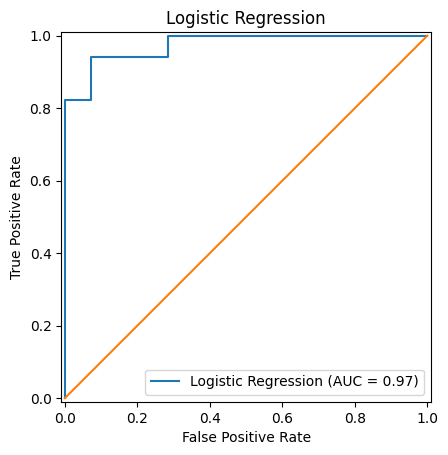

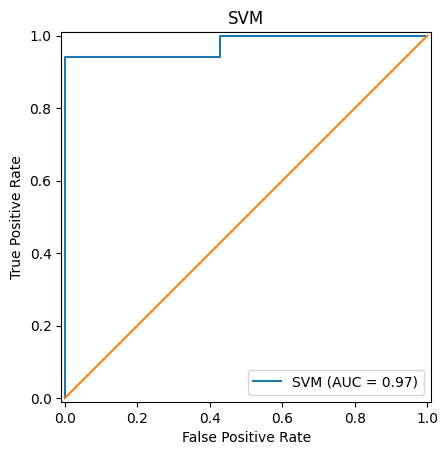

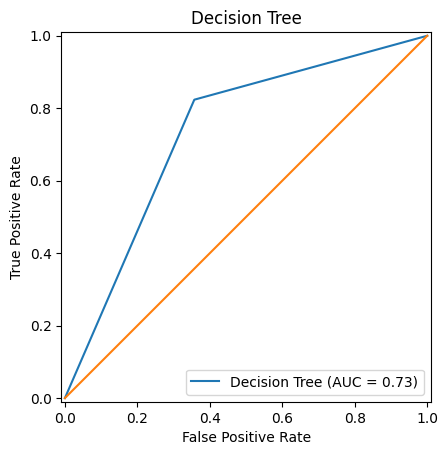

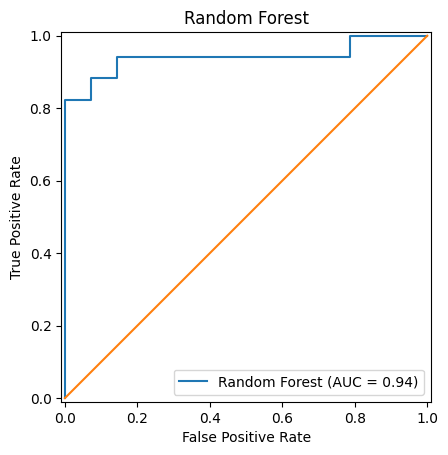

In [119]:
calls_without_cross_validation()

In [105]:

cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=5)

def calls_with_cross_validation():
    for model in models:
        classifier = models[model]
        scores=cross_val_score(classifier,attributes,target)
        print(f"the accuracy for {classifier}\n {scores.mean()}")

In [106]:
calls_with_cross_validation()

the accuracy for LogisticRegression(random_state=5)
 0.8475956284153006
the accuracy for SVC(probability=True, random_state=5)
 0.8177049180327869
the accuracy for DecisionTreeClassifier(random_state=5)
 0.7381967213114754
the accuracy for RandomForestClassifier(random_state=5)
 0.7879234972677596


In [107]:
from sklearn.model_selection import GridSearchCV
log_reg_new = LogisticRegression()
parameters = {"penalty":["l1","l2"], "solver" : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']}
log_reg_grid = GridSearchCV(log_reg_new, param_grid = parameters)
log_reg_grid.fit(attributes_train, target_train)
print("Best Parameters: ", log_reg_grid.best_params_)

Best Parameters:  {'penalty': 'l2', 'solver': 'newton-cg'}


In [109]:
log_reg_new2 = LogisticRegression(penalty = "l2", solver = "newton-cg")
scores = cross_val_score(log_reg_new2, attributes, target, cv=cv)
print(f"Cross-Validation Accuracy Scores for {log_reg_new2}", scores.mean())

Cross-Validation Accuracy Scores for LogisticRegression(solver='newton-cg') 0.8478494623655914
